<a href="https://colab.research.google.com/github/24ukandev-blip/icecream_sales/blob/main/icecream_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/icecream_sales_full_dataset.csv")

In [ ]:
print(df)

           Date  Temperature_C  Humidity_% Weather  Wind_Speed_kmph  Holiday  \
0    01-01-2023          34.38       26.14  Cloudy             1.94        0   
1    02-01-2023          20.01       57.13   Sunny            19.55        0   
2    03-01-2023          17.94       41.67  Cloudy             1.47        0   
3    04-01-2023          29.30       68.00   Windy            19.03        0   
4    05-01-2023          35.18       57.50  Cloudy            21.11        1   
..          ...            ...         ...     ...              ...      ...   
995  22-09-2025          19.25       34.48   Rainy            19.57        0   
996  23-09-2025          34.18       74.87   Rainy            14.22        0   
997  24-09-2025          22.15       40.60   Windy            18.03        1   
998  25-09-2025          10.15       74.14   Sunny            12.01        0   
999  26-09-2025          20.32       27.34  Cloudy            22.67        0   

     Weekend IceCream_Flavour      Vari

In [ ]:
# Part 1: Import libraries and load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Upload your CSV file
from google.colab import files
uploaded = files.upload()

# Load the dataset (assuming filename is 'icecream_sales.csv' – change if needed)
filename = list(uploaded.keys())[0]
df = pd.read_csv("/content/icecream_sales_full_dataset.csv")
print("✅ Dataset loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Saving icecream_sales_full_dataset.csv to icecream_sales_full_dataset (1).csv
✅ Dataset loaded successfully
Shape: (1000, 16)


,Date,Temperature_C,Humidity_%,Weather,Wind_Speed_kmph,Holiday,Weekend,IceCream_Flavour,Variety,Store_Location,Price_per_Unit,Promotion,Units_Sold,Per_Day_Revenue,Monthly_Revenue,Yearly_Revenue
0,01-01-2023,34.38,26.14,Cloudy,1.94,0,1,Butterscotch,Cup,Semi-Urban,64.00,0,45,2880.00,80640.0,967680.0
1,02-01-2023,20.01,57.13,Sunny,19.55,0,1,Strawberry,Stick,Rural,63.90,0,23,1469.70,35272.8,423273.6
2,03-01-2023,17.94,41.67,Cloudy,1.47,0,1,Butterscotch,Stick,Rural,52.27,0,33,1724.91,34498.2,413978.4
3,04-01-2023,29.30,68.00,Windy,19.03,0,1,Pista,Cup,Rural,88.00,1,23,2024.00,50600.0,607200.0
4,05-01-2023,35.18,57.50,Cloudy,21.11,1,1,Butterscotch,Cone,Semi-Urban,32.22,1,101,3254.22,65084.4,781012.8


In [ ]:
print("="*60)
print("1. Dataset Info")
print("="*60)
df.info()


1. Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1000 non-null   object 
 1   Temperature_C     1000 non-null   float64
 2   Humidity_%        1000 non-null   float64
 3   Weather           1000 non-null   object 
 4   Wind_Speed_kmph   1000 non-null   float64
 5   Holiday           1000 non-null   int64  
 6   Weekend           1000 non-null   int64  
 7   IceCream_Flavour  1000 non-null   object 
 8   Variety           1000 non-null   object 
 9   Store_Location    1000 non-null   object 
 10  Price_per_Unit    1000 non-null   float64
 11  Promotion         1000 non-null   int64  
 12  Units_Sold        1000 non-null   int64  
 13  Per_Day_Revenue   1000 non-null   float64
 14  Monthly_Revenue   1000 non-null   float64
 15  Yearly_Revenue    1000 non-null   float64
dtypes: float64(7), int64(4), ob

In [ ]:
print("\n" + "="*60)
print("2. Missing Values Check")
print("="*60)
print(df.isnull().sum())


2. Missing Values Check
Date                0
Temperature_C       0
Humidity_%          0
Weather             0
Wind_Speed_kmph     0
Holiday             0
Weekend             0
IceCream_Flavour    0
Variety             0
Store_Location      0
Price_per_Unit      0
Promotion           0
Units_Sold          0
Per_Day_Revenue     0
Monthly_Revenue     0
Yearly_Revenue      0
dtype: int64


In [ ]:
print("\n" + "="*60)
print("3. Statistical Summary (Numerical Features)")
print("="*60)
display(df.describe())


3. Statistical Summary (Numerical Features)


,Temperature_C,Humidity_%,Wind_Speed_kmph,Holiday,Weekend,Price_per_Unit,Promotion,Units_Sold,Per_Day_Revenue,Monthly_Revenue,Yearly_Revenue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1.000000e+03
mean,27.478000,57.508830,12.720260,0.506000,0.49000,59.562720,0.482000,40.028000,2345.45482,57803.002870,6.936360e+05
std,9.977787,22.511702,7.168818,0.500214,0.50015,22.564192,0.499926,34.203964,2222.16573,56648.162329,6.797779e+05
min,10.000000,20.010000,0.000000,0.000000,0.00000,20.040000,0.000000,1.000000,26.77000,669.250000,8.031000e+03
25%,19.250000,37.152500,6.467500,0.000000,0.00000,39.627500,0.000000,15.000000,798.47000,19817.730000,2.378128e+05
50%,27.100000,58.000000,12.960000,1.000000,0.00000,60.060000,0.000000,30.000000,1579.59000,38294.800000,4.595376e+05
75%,35.832500,77.300000,18.882500,1.000000,1.00000,78.682500,1.000000,55.000000,3211.17000,78952.350000,9.474282e+05
max,44.960000,94.970000,24.870000,1.000000,1.00000,99.910000,1.000000,245.000000,15534.48000,419430.960000,5.033172e+06


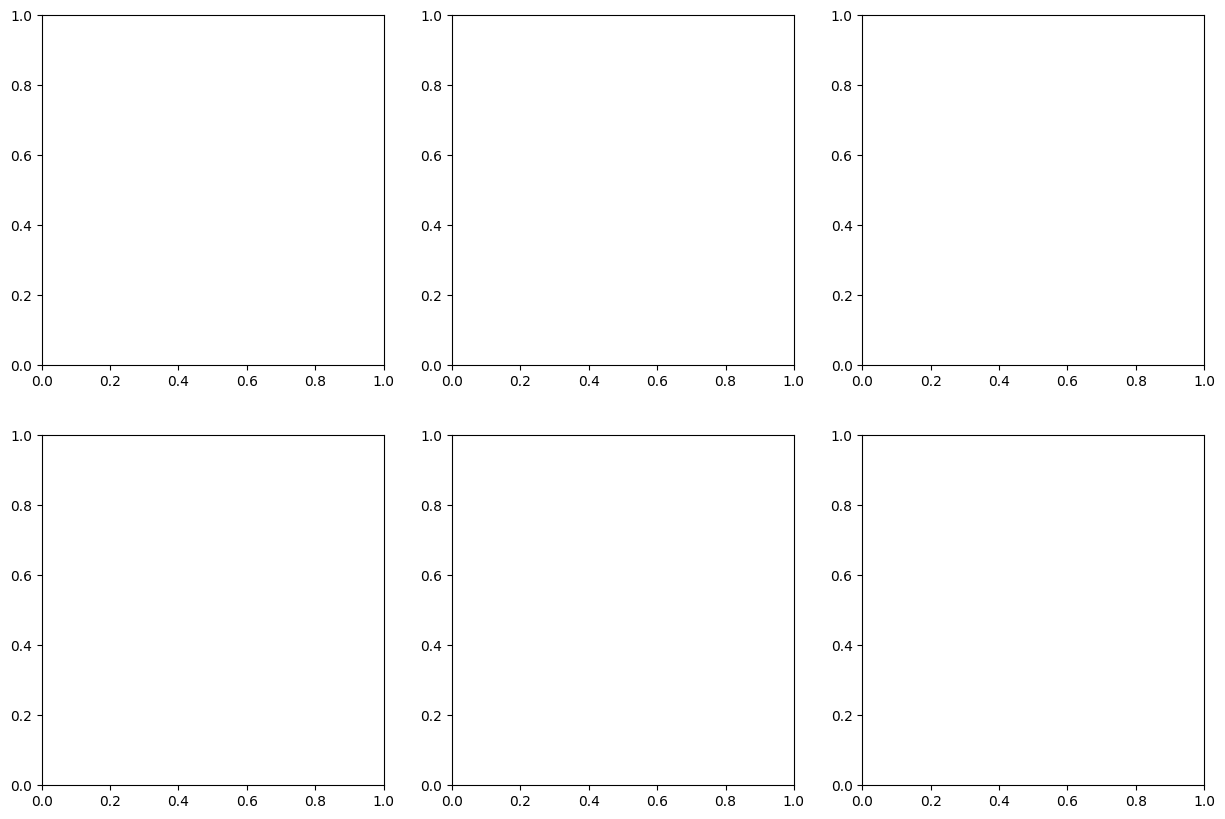

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
num_cols = ['Temperature_C', 'Humidity_%', 'Wind_Speed_kmph', 'Price_per_Unit', 'Promotion', 'Units_Sold']

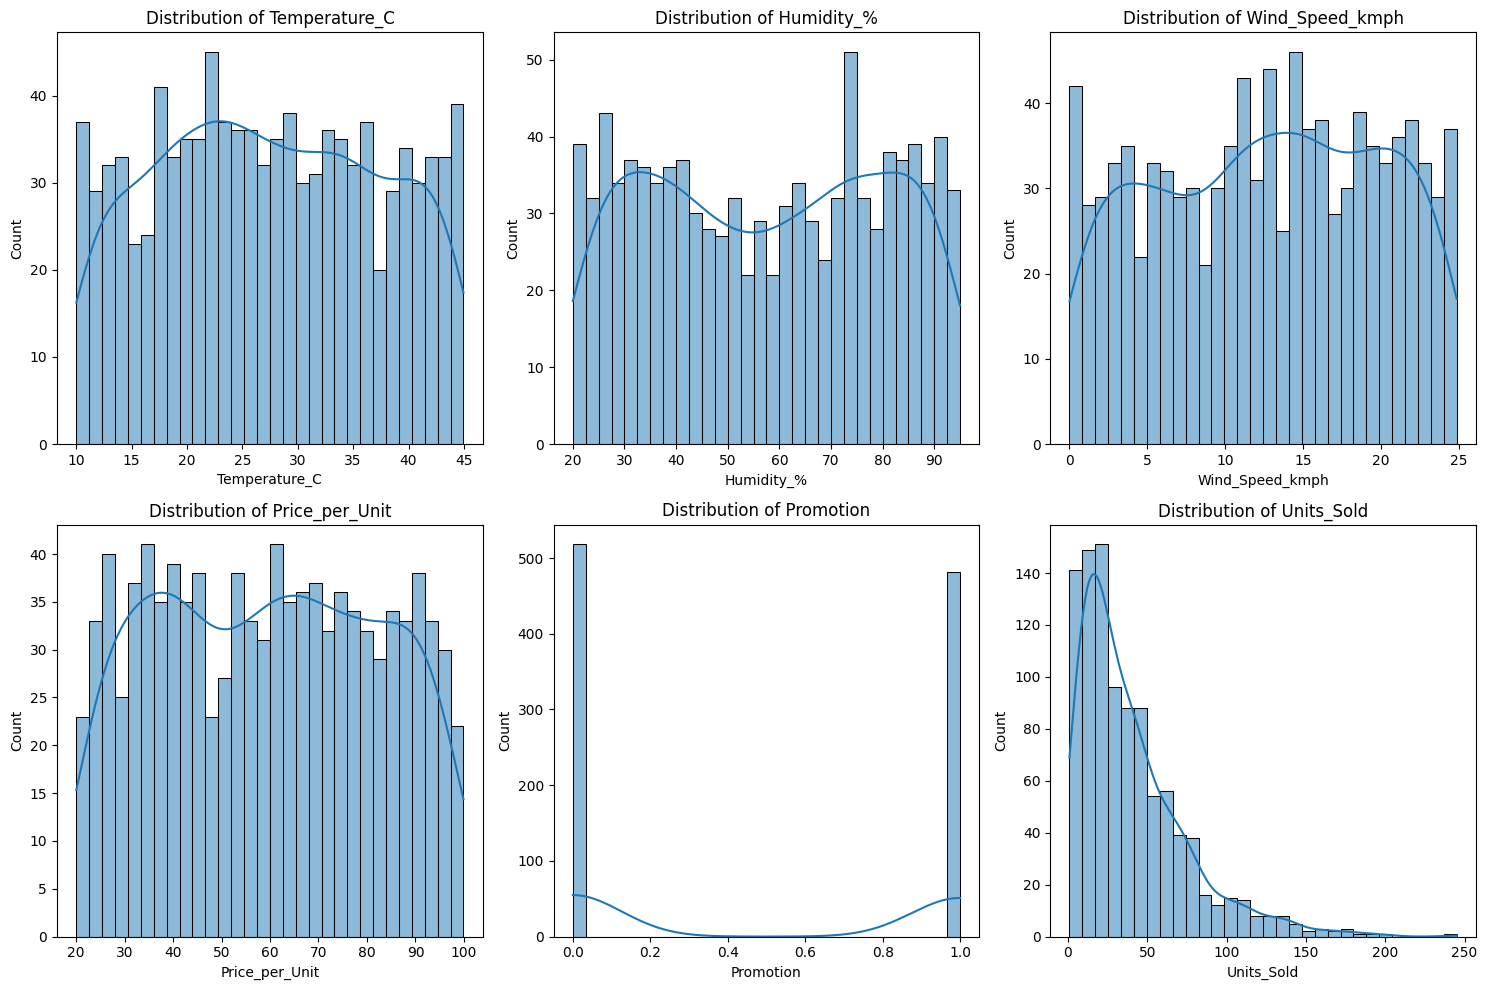

In [ ]:
# Plot distributions of key numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
num_cols = ['Temperature_C', 'Humidity_%', 'Wind_Speed_kmph', 'Price_per_Unit', 'Promotion', 'Units_Sold']
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

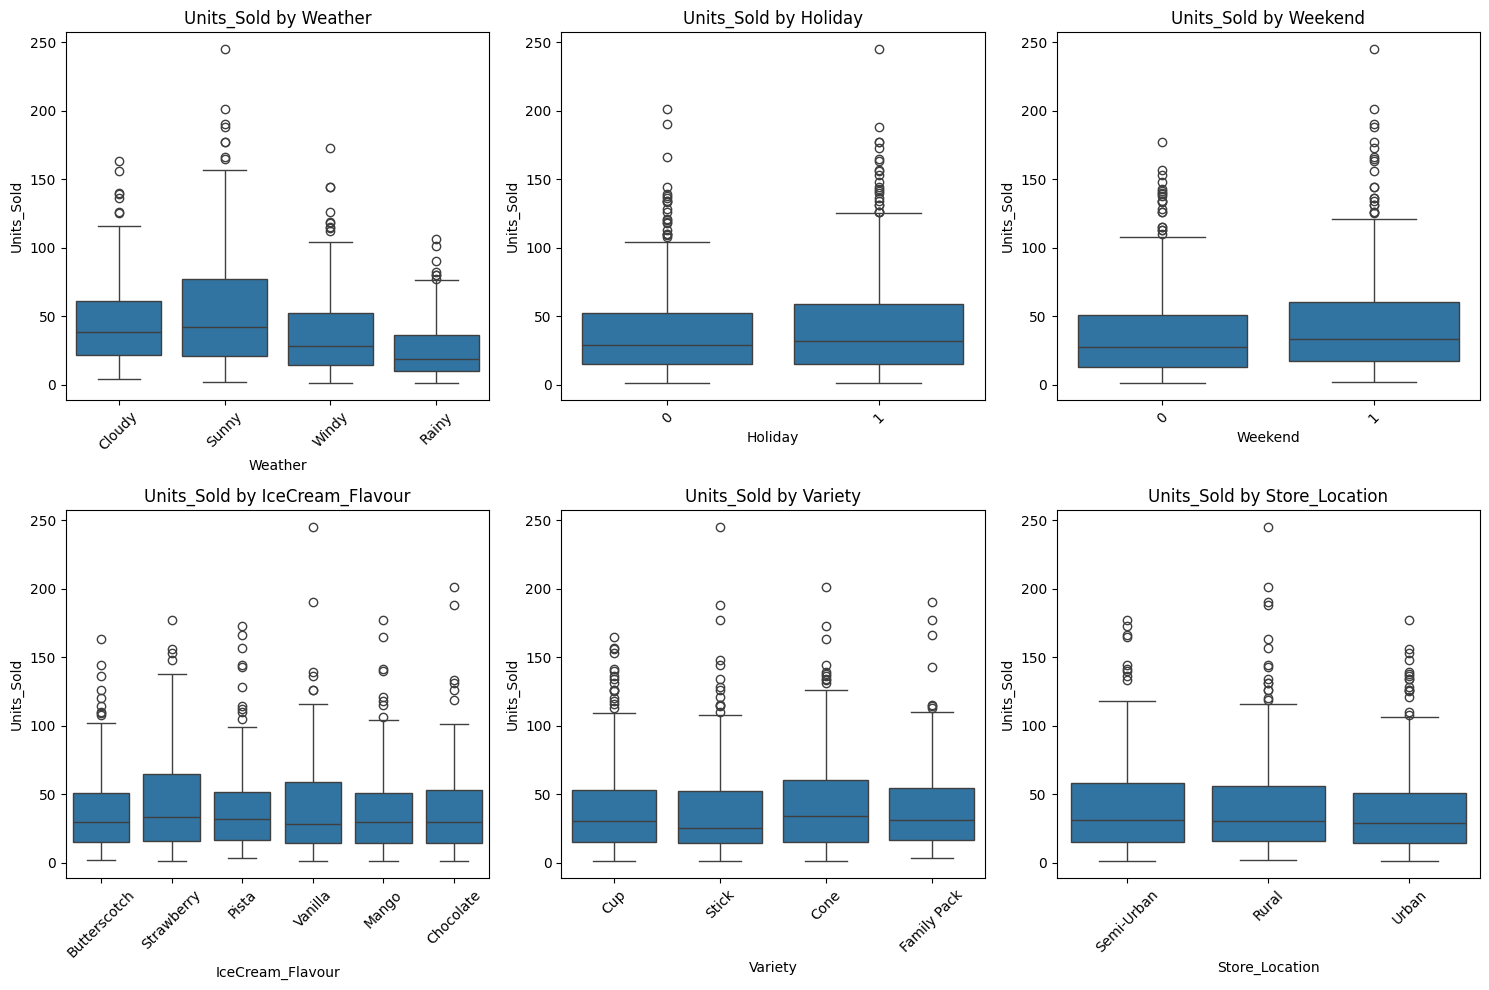

In [ ]:
cat_cols = ['Weather', 'Holiday', 'Weekend', 'IceCream_Flavour', 'Variety', 'Store_Location']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.boxplot(x=col, y='Units_Sold', data=df, ax=ax)
    ax.set_title(f'Units_Sold by {col}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

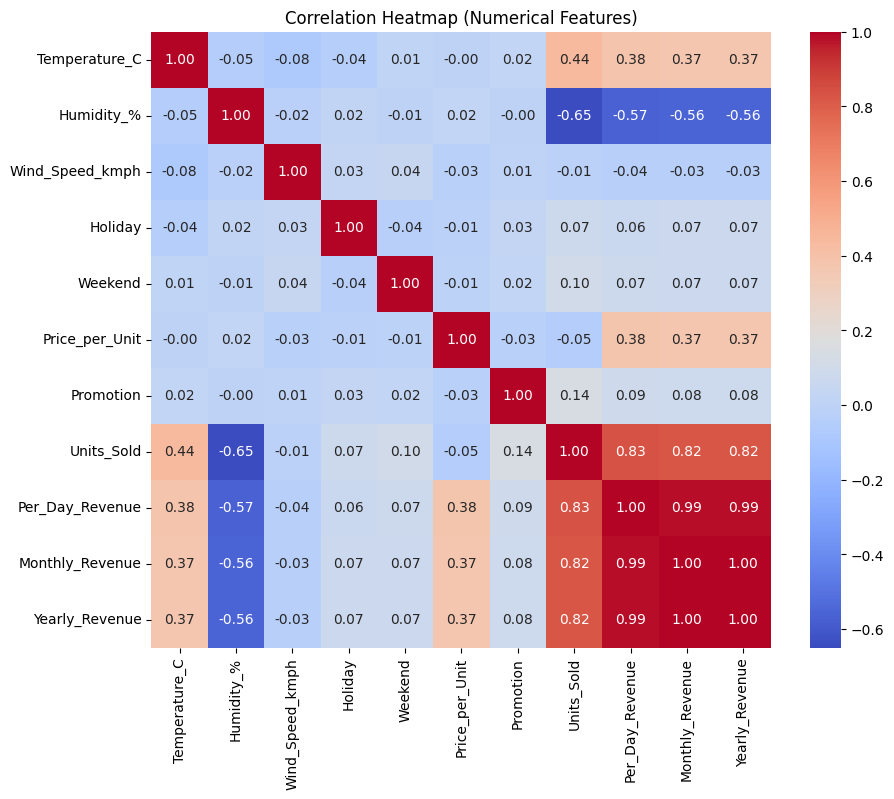

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()

In [ ]:
q33 = df['Units_Sold'].quantile(0.33)
q66 = df['Units_Sold'].quantile(0.66)
def categorize_sales(units):
    if units <= q33:
        return 'Low'
    elif units <= q66:
        return 'Medium'
    else:
        return 'High'

df['Sales_Category'] = df['Units_Sold'].apply(categorize_sales)
print(f"Target distribution:\n{df['Sales_Category'].value_counts()}")

Target distribution:
Sales_Category
High      336
Low       335
Medium    329
Name: count, dtype: int64


In [ ]:
drop_cols = ['Date', 'Units_Sold', 'Per_Day_Revenue', 'Monthly_Revenue', 'Yearly_Revenue']
X = df.drop(columns=drop_cols + ['Sales_Category'])
y = df['Sales_Category']


In [ ]:
numeric_features = ['Temperature_C', 'Humidity_%', 'Wind_Speed_kmph', 'Price_per_Unit', 'Promotion']
categorical_features = ['Weather', 'IceCream_Flavour', 'Variety', 'Store_Location']
binary_features = ['Holiday', 'Weekend']  # already 0/1

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ])

In [ ]:
# Fit preprocessor on whole X (for later GUI use)
preprocessor.fit(X)

# Transform features
X_processed = preprocessor.transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Preprocessing done. Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

✅ Preprocessing done. Train size: 800, Test size: 200


In [ ]:
# Part 3b: Advanced Feature Engineering (add before preprocessing)
# Capture original columns before adding new ones
original_cols = df.columns.tolist()

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Extract temporal features
df['Day_of_Week'] = df['Date'].dt.dayofweek  # Monday=0, Sunday=6
df['Month'] = df['Date'].dt.month
df['Day_of_Month'] = df['Date'].dt.day
df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)  # Saturday=5, Sunday=6
df['Season'] = df['Month'].map({12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3})  # 0=Winter,1=Spring,2=Summer,3=Fall

# Interaction features (key for sales)
df['Temp_Humidity'] = df['Temperature_C'] * df['Humidity_%'] / 100
df['Temp_Promo'] = df['Temperature_C'] * df['Promotion']
df['Humidity_Weekend'] = df['Humidity_%'] * df['Weekend']
df['Price_Promo'] = df['Price_per_Unit'] * df['Promotion']

# Lag features (if data is chronological – sort by Date first)
df = df.sort_values('Date')
df['Units_Sold_Lag1'] = df['Units_Sold'].shift(1)
# Fill first row NaN with median
df['Units_Sold_Lag1'].fillna(df['Units_Sold'].median(), inplace=True)

# Rolling average (last 7 days)
df['Units_Sold_MA7'] = df['Units_Sold'].rolling(window=7, min_periods=1).mean().fillna(df['Units_Sold'].median())

print("✅ Added engineered features. New columns:", [c for c in df.columns if c not in original_cols])

✅ Added engineered features. New columns: []


In [ ]:
# Part 4: Advanced models + hyperparameter tuning for max accuracy
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
import time
from sklearn.preprocessing import LabelEncoder

# Use all features except original target and revenue columns
drop_cols = ['Date', 'Units_Sold', 'Per_Day_Revenue', 'Monthly_Revenue', 'Yearly_Revenue']
X = df.drop(columns=drop_cols + ['Sales_Category'])
y = df['Sales_Category']

# Encode target variable labels to numerical values
le = LabelEncoder()
y = le.fit_transform(y)

# Redefine numeric and categorical features (include new ones)
numeric_features = ['Temperature_C', 'Humidity_%', 'Wind_Speed_kmph', 'Price_per_Unit',
                    'Promotion', 'Day_of_Week', 'Month', 'Day_of_Month', 'Is_Weekend', 'Season',
                    'Temp_Humidity', 'Temp_Promo', 'Humidity_Weekend', 'Price_Promo',
                    'Units_Sold_Lag1', 'Units_Sold_MA7']
categorical_features = ['Weather', 'IceCream_Flavour', 'Variety', 'Store_Location']
binary_features = ['Holiday', 'Weekend']

# Preprocessor (same as before but updated numeric list)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('bin', 'passthrough', binary_features)
    ])

X_processed = preprocessor.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

# Models with tuned parameters (focus on high accuracy)
models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, eval_metric='mlogloss'),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42)
}

results = []
best_model = None
best_acc = 0

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name}: Test Acc = {acc:.4f}, CV Mean = {cv_scores.mean():.4f}")
    results.append({'Model': name, 'Test Accuracy': acc, 'CV Mean': cv_scores.mean()})
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_model_name = name

comparison_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n🏆 BEST MODEL:", best_model_name, "with Accuracy:", best_acc)
display(comparison_df)

Random Forest: Test Acc = 0.7400, CV Mean = 0.7675
Gradient Boosting: Test Acc = 0.7200, CV Mean = 0.7350
XGBoost: Test Acc = 0.7050, CV Mean = 0.7388
AdaBoost: Test Acc = 0.7050, CV Mean = 0.7400

🏆 BEST MODEL: Random Forest with Accuracy: 0.74


,Model,Test Accuracy,CV Mean
0,Random Forest,0.740,0.76750
1,Gradient Boosting,0.720,0.73500
2,XGBoost,0.705,0.73875
3,AdaBoost,0.705,0.74000


In [ ]:
# Part 5: Hyperparameter tuning for the best model (optional but helps)
if best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [200, 300, 500],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1]
    }
    grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'),
                        param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    best_acc = grid.best_score_
    print(f"Tuned XGBoost CV Accuracy: {best_acc:.4f}")
    print("Best params:", grid.best_params_)
    y_pred_best = best_model.predict(X_test)
    best_acc_test = accuracy_score(y_test, y_pred_best)
    print(f"Test Accuracy after tuning: {best_acc_test:.4f}")
else:
    # For Random Forest or Gradient Boosting
    if best_model_name == 'Random Forest':
        param_grid = {'n_estimators': [200, 400], 'max_depth': [15, 20, 25], 'min_samples_split': [2,5]}
        model_base = RandomForestClassifier(random_state=42)
    else:
        param_grid = {'n_estimators': [200, 300], 'learning_rate': [0.05, 0.1], 'max_depth': [4,5,6]}
        model_base = GradientBoostingClassifier(random_state=42)
    grid = GridSearchCV(model_base, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred_best = best_model.predict(X_test)
    best_acc_test = accuracy_score(y_test, y_pred_best)
    print(f"Tuned {best_model_name} Test Accuracy: {best_acc_test:.4f}")

Tuned Random Forest Test Accuracy: 0.7500



✅ FINAL TEST ACCURACY: 75.00%


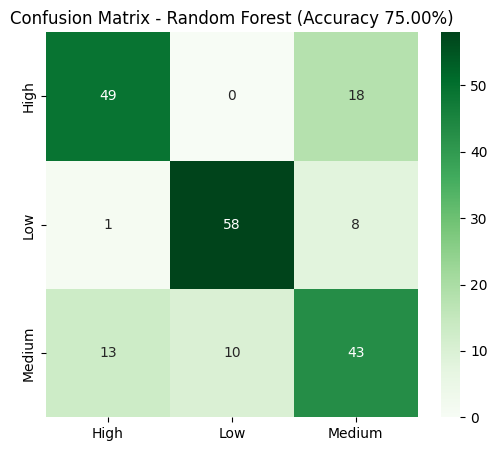

              precision    recall  f1-score   support

        High       0.78      0.73      0.75        67
         Low       0.85      0.87      0.86        67
      Medium       0.62      0.65      0.64        66

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200



In [ ]:
# Part 6: Final evaluation with best model
print(f"\n✅ FINAL TEST ACCURACY: {best_acc_test:.2%}")

# Get the original string labels for plotting
class_names = le.inverse_transform([0, 1, 2])

cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1, 2]) # Use numerical labels for confusion_matrix calculation
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f'Confusion Matrix - {best_model_name} (Accuracy {best_acc_test:.2%})')
plt.show()
print(classification_report(y_test, y_pred_best, target_names=class_names))

In [ ]:
# Save model and preprocessor as pickle files
import joblib

# Save the best model
joblib.dump(best_model, 'best_icecream_model.pkl')
# Save the preprocessor (includes all feature engineering steps)
joblib.dump(preprocessor, 'preprocessor.pkl')

print("✅ Pickle files saved successfully:")
print("   - best_icecream_model.pkl")
print("   - preprocessor.pkl")

# Optional: Download them to your local machine
from google.colab import files
files.download('best_icecream_model.pkl')
files.download('preprocessor.pkl')

✅ Pickle files saved successfully:
   - best_icecream_model.pkl
   - preprocessor.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 98.0 MB/s eta 0:00:00


In [ ]:
# app.py - Ice Cream Sales Prediction with Streamlit
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import os
from datetime import datetime

# Page config
st.set_page_config(page_title="Ice Cream Sales Predictor", layout="wide")
st.title("🍦 Ice Cream Sales Prediction")
st.markdown("Upload your dataset, train a model, and predict sales category (Low/Medium/High).")

# Sidebar for navigation
st.sidebar.header("Navigation")
option = st.sidebar.radio("Go to", ["Train Model", "Single Prediction", "Batch Prediction"])

# Global variables to store trained model and preprocessor
if 'model' not in st.session_state:
    st.session_state.model = None
if 'preprocessor' not in st.session_state:
    st.session_state.preprocessor = None
if 'feature_cols' not in st.session_state:
    st.session_state.feature_cols = None
if 'target_col' not in st.session_state:
    st.session_state.target_col = 'Sales_Category'

# ------------------- TRAIN MODEL SECTION -------------------
if option == "Train Model":
    st.header("📊 Step 1: Upload & Train Model")

    uploaded_file = st.file_uploader("Upload your ice cream sales CSV", type=["csv"])

    if uploaded_file is not None:
        df = pd.read_csv(uploaded_file)
        st.success("Dataset loaded successfully!")
        st.write("Preview:", df.head())

        # Basic info
        st.subheader("Dataset Info")
        col1, col2, col3 = st.columns(3)
        col1.metric("Rows", df.shape[0])
        col2.metric("Columns", df.shape[1])
        col3.metric("Missing Values", df.isnull().sum().sum())

        # EDA: Show distributions
        st.subheader("Exploratory Data Analysis")
        if st.checkbox("Show numerical distributions"):
            fig, axes = plt.subplots(2, 3, figsize=(12, 8))
            num_cols = ['Temperature_C', 'Humidity_%', 'Wind_Speed_kmph', 'Price_per_Unit', 'Promotion', 'Units_Sold']
            for ax, col in zip(axes.flatten(), num_cols):
                if col in df.columns:
                    sns.histplot(df[col], bins=30, kde=True, ax=ax)
                    ax.set_title(col)
            st.pyplot(fig)

        # Feature engineering (same as before)
        st.subheader("Feature Engineering")
        # Convert Date
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
        df['Day_of_Week'] = df['Date'].dt.dayofweek
        df['Month'] = df['Date'].dt.month
        df['Day_of_Month'] = df['Date'].dt.day
        df['Is_Weekend'] = (df['Day_of_Week'] >= 5).astype(int)

        def get_season(month):
            if month in [12,1,2]: return 0
            elif month in [3,4,5]: return 1
            elif month in [6,7,8]: return 2
            else: return 3
        df['Season'] = df['Month'].apply(get_season)

        # Interactions
        df['Temp_Humidity'] = df['Temperature_C'] * df['Humidity_%'] / 100
        df['Temp_Promo'] = df['Temperature_C'] * df['Promotion']
        df['Humidity_Weekend'] = df['Humidity_%'] * df['Weekend']
        df['Price_Promo'] = df['Price_per_Unit'] * df['Promotion']

        # Lag features (simple median placeholder for simplicity)
        median_units = df['Units_Sold'].median()
        df['Units_Sold_Lag1'] = median_units
        df['Units_Sold_MA7'] = median_units

        # Create target (Low/Medium/High) based on Units_Sold quantiles
        q33 = df['Units_Sold'].quantile(0.33)
        q66 = df['Units_Sold'].quantile(0.66)
        def categorize(units):
            if units <= q33: return 'Low'
            elif units <= q66: return 'Medium'
            else: return 'High'
        df['Sales_Category'] = df['Units_Sold'].apply(categorize)

        st.write("Target distribution:", df['Sales_Category'].value_counts().to_dict())

        # Define features and target
        drop_cols = ['Date', 'Units_Sold', 'Per_Day_Revenue', 'Monthly_Revenue', 'Yearly_Revenue', 'Sales_Category']
        X = df.drop(columns=drop_cols)
        y = df['Sales_Category']

        # Column types
        numeric_features = ['Temperature_C', 'Humidity_%', 'Wind_Speed_kmph', 'Price_per_Unit',
                            'Promotion', 'Day_of_Week', 'Month', 'Day_of_Month', 'Is_Weekend', 'Season',
                            'Temp_Humidity', 'Temp_Promo', 'Humidity_Weekend', 'Price_Promo',
                            'Units_Sold_Lag1', 'Units_Sold_MA7']
        categorical_features = ['Weather', 'IceCream_Flavour', 'Variety', 'Store_Location']
        binary_features = ['Holiday', 'Weekend']

        # Preprocessor
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), numeric_features),
                ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
                ('bin', 'passthrough', binary_features)
            ])

        X_processed = preprocessor.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

        # Model training
        st.subheader("Model Training & Comparison")
        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Decision Tree': DecisionTreeClassifier(random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(random_state=42),
            'SVM (RBF)': SVC(kernel='rbf', random_state=42)
        }

        results = []
        best_model = None
        best_acc = 0
        progress_bar = st.progress(0)
        for i, (name, model) in enumerate(models.items()):
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            results.append({'Model': name, 'Test Accuracy': acc})
            if acc > best_acc:
                best_acc = acc
                best_model = model
            progress_bar.progress((i+1)/len(models))
        progress_bar.empty()

        results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
        st.table(results_df)

        st.success(f"🏆 Best Model: {results_df.iloc[0]['Model']} with Accuracy: {results_df.iloc[0]['Test Accuracy']:.2%}")

        # Confusion matrix for best model
        y_pred_best = best_model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred_best, labels=['Low','Medium','High'])
        fig, ax = plt.subplots(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Low','Medium','High'],
                    yticklabels=['Low','Medium','High'], ax=ax)
        ax.set_title(f'Confusion Matrix - {results_df.iloc[0]["Model"]}')
        st.pyplot(fig)

        st.text("Classification Report:")
        st.text(classification_report(y_test, y_pred_best))

        # Save model and preprocessor to session state and disk
        st.session_state.model = best_model
        st.session_state.preprocessor = preprocessor
        st.session_state.feature_cols = list(X.columns)

        joblib.dump(best_model, 'best_model.pkl')
        joblib.dump(preprocessor, 'preprocessor.pkl')
        st.success("✅ Model and preprocessor saved as 'best_model.pkl' and 'preprocessor.pkl'")

        # Optional download buttons
        with open('best_model.pkl', 'rb') as f:
            st.download_button("Download model", f, file_name="best_model.pkl")
        with open('preprocessor.pkl', 'rb') as f:
            st.download_button("Download preprocessor", f, file_name="preprocessor.pkl")
    else:
        st.info("Please upload a CSV file to begin training.")

# ------------------- SINGLE PREDICTION SECTION -------------------
elif option == "Single Prediction":
    st.header("🎯 Predict Sales Category for a Single Day")

    if st.session_state.model is None:
        st.warning("No trained model found. Please go to 'Train Model' first and train a model.")
    else:
        # Input widgets
        col1, col2 = st.columns(2)
        with col1:
            date = st.date_input("Date", datetime.today())
            temp = st.slider("Temperature (°C)", -5.0, 45.0, 25.0, 0.5)
            humidity = st.slider("Humidity (%)", 0.0, 100.0, 50.0, 1.0)
            wind = st.slider("Wind Speed (km/h)", 0.0, 50.0, 10.0, 0.5)
            weather = st.selectbox("Weather", ['Sunny','Cloudy','Rainy','Windy'])
            holiday = st.checkbox("Holiday")
            weekend = st.checkbox("Weekend")
        with col2:
            flavour = st.selectbox("Ice Cream Flavour", ['Vanilla','Chocolate','Strawberry','Mango','Butterscotch','Pista'])
            variety = st.selectbox("Variety", ['Cone','Cup','Stick','Family Pack'])
            location = st.selectbox("Store Location", ['Urban','Semi-Urban','Rural'])
            price = st.slider("Price per Unit (₹)", 10.0, 150.0, 50.0, 0.5)
            promo = st.selectbox("Promotion (0=No, 1=Yes)", [0,1])

        if st.button("Predict"):
            # Compute engineered features
            date_obj = pd.to_datetime(date)
            day_of_week = date_obj.dayofweek
            month = date_obj.month
            day_of_month = date_obj.day
            is_weekend = 1 if day_of_week >= 5 else 0
            if month in [12,1,2]: season = 0
            elif month in [3,4,5]: season = 1
            elif month in [6,7,8]: season = 2
            else: season = 3

            temp_hum = temp * humidity / 100
            temp_promo = temp * promo
            hum_weekend = humidity * weekend
            price_promo = price * promo
            lag_median = 50  # fallback

            input_dict = {
                'Temperature_C': [temp], 'Humidity_%': [humidity], 'Wind_Speed_kmph': [wind],
                'Weather': [weather], 'Holiday': [int(holiday)], 'Weekend': [int(weekend)],
                'IceCream_Flavour': [flavour], 'Variety': [variety], 'Store_Location': [location],
                'Price_per_Unit': [price], 'Promotion': [promo],
                'Day_of_Week': [day_of_week], 'Month': [month], 'Day_of_Month': [day_of_month],
                'Is_Weekend': [is_weekend], 'Season': [season],
                'Temp_Humidity': [temp_hum], 'Temp_Promo': [temp_promo],
                'Humidity_Weekend': [hum_weekend], 'Price_Promo': [price_promo],
                'Units_Sold_Lag1': [lag_median], 'Units_Sold_MA7': [lag_median]
            }
            input_df = pd.DataFrame(input_dict)
            X_input = st.session_state.preprocessor.transform(input_df)
            pred = st.session_state.model.predict(X_input)[0]
            st.success(f"🍦 Predicted Sales Category: **{pred}**")

# ------------------- BATCH PREDICTION SECTION -------------------
elif option == "Batch Prediction":
    st.header("📂 Batch Prediction – Upload a CSV File")

    if st.session_state.model is None:
        st.warning("No trained model found. Please go to 'Train Model' first and train a model.")
    else:
        batch_file = st.file_uploader("Upload CSV for prediction (must contain same feature columns)", type=["csv"])
        if batch_file is not None:
            df_batch = pd.read_csv(batch_file)
            st.write("Preview of uploaded file:", df_batch.head())

            required_cols = ['Temperature_C', 'Humidity_%', 'Wind_Speed_kmph', 'Weather',
                             'Holiday', 'Weekend', 'IceCream_Flavour', 'Variety',
                             'Store_Location', 'Price_per_Unit', 'Promotion', 'Date']
            if all(col in df_batch.columns for col in required_cols):
                # Apply same feature engineering
                df_batch['Date'] = pd.to_datetime(df_batch['Date'], dayfirst=True, errors='coerce')
                df_batch['Day_of_Week'] = df_batch['Date'].dt.dayofweek
                df_batch['Month'] = df_batch['Date'].dt.month
                df_batch['Day_of_Month'] = df_batch['Date'].dt.day
                df_batch['Is_Weekend'] = (df_batch['Day_of_Week'] >= 5).astype(int)
                def get_season(m):
                    if m in [12,1,2]: return 0
                    elif m in [3,4,5]: return 1
                    elif m in [6,7,8]: return 2
                    else: return 3
                df_batch['Season'] = df_batch['Month'].apply(get_season)
                df_batch['Temp_Humidity'] = df_batch['Temperature_C'] * df_batch['Humidity_%'] / 100
                df_batch['Temp_Promo'] = df_batch['Temperature_C'] * df_batch['Promotion']
                df_batch['Humidity_Weekend'] = df_batch['Humidity_%'] * df_batch['Weekend']
                df_batch['Price_Promo'] = df_batch['Price_per_Unit'] * df_batch['Promotion']
                # Placeholder for lag
                df_batch['Units_Sold_Lag1'] = 50
                df_batch['Units_Sold_MA7'] = 50

                feature_cols = st.session_state.feature_cols
                X_batch = st.session_state.preprocessor.transform(df_batch[feature_cols])
                predictions = st.session_state.model.predict(X_batch)
                df_batch['Predicted_Sales_Category'] = predictions
                st.success("Predictions added!")
                st.dataframe(df_batch[['Date', 'Temperature_C', 'Predicted_Sales_Category']].head(10))

                # Download button
                csv_output = df_batch.to_csv(index=False).encode('utf-8')
                st.download_button("Download predictions as CSV", csv_output, file_name="batch_predictions.csv")
            else:
                missing = set(required_cols) - set(df_batch.columns)
                st.error(f"Missing columns: {missing}")

2026-04-07 14:01:36.805 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 14:01:36.807 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 14:01:37.324 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-07 14:01:37.333 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 14:01:37.336 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 14:01:37.343 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-07 14:01:37.347 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn